In [4]:
!pip install opencv-python

  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl (40.2 MB)


In [40]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.image as mpimg
import numpy as np
import cv2
from PIL import Image 
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras

import os

import warnings
warnings.filterwarnings('ignore')

In [42]:
with_mask = os.listdir('C:/Users/LOQ/Desktop/Prabhat Rai/Face Mask Detection/data/with_mask')

In [43]:
print(with_mask[0:5])

['with_mask_1.jpg', 'with_mask_10.jpg', 'with_mask_100.jpg', 'with_mask_1000.jpg', 'with_mask_1001.jpg']


In [44]:
len(with_mask)

3725

In [45]:
without_mask = os.listdir('C:/Users/LOQ/Desktop/Prabhat Rai/Face Mask Detection/data/without_mask')

In [46]:
print(without_mask[0:5])

['without_mask_1.jpg', 'without_mask_10.jpg', 'without_mask_100.jpg', 'without_mask_1000.jpg', 'without_mask_1001.jpg']


In [47]:

with_mask_labels = [1]*3725

without_mask_labels = [0]*3828

In [48]:

without_mask_labels[0:5]

[0, 0, 0, 0, 0]

In [49]:
labels = with_mask_labels + without_mask_labels

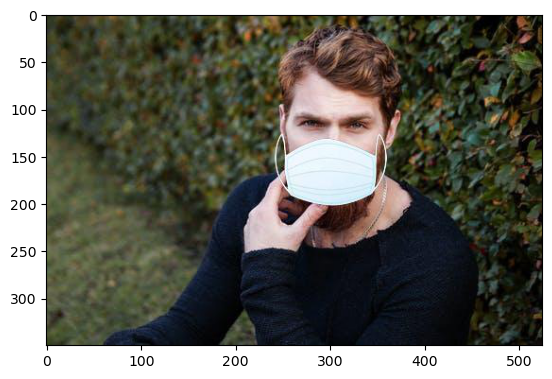

In [50]:
img = mpimg.imread('C:/Users/LOQ/Desktop/Prabhat Rai/Face Mask Detection/data/with_mask/with_mask_1.jpg')
imgplot = plt.imshow(img)
plt.show()

In [51]:
import os
import numpy as np
from PIL import Image

# Paths
with_mask_path = r"C:/Users/LOQ/Desktop/Prabhat Rai/Face Mask Detection/data/with_mask"
without_mask_path = r"C:/Users/LOQ/Desktop/Prabhat Rai/Face Mask Detection/data/without_mask"

# Get file names
with_mask_files = os.listdir(with_mask_path)
without_mask_files = os.listdir(without_mask_path)

# Data and labels
data = []
labels = []

# Load with_mask images
for img_file in with_mask_files:

    img_path = os.path.join(with_mask_path, img_file)

    try:
        image = Image.open(img_path)
        image = image.resize((128, 128))
        image = image.convert("RGB")
        image = np.array(image)

        data.append(image)
        labels.append(0)   # with_mask = 0

    except Exception as e:
        print(f"Error loading {img_file}: {e}")

# Load without_mask images
for img_file in without_mask_files:

    img_path = os.path.join(without_mask_path, img_file)

    try:
        image = Image.open(img_path)
        image = image.resize((128, 128))
        image = image.convert("RGB")
        image = np.array(image)

        data.append(image)
        labels.append(1)   # without_mask = 1

    except Exception as e:
        print(f"Error loading {img_file}: {e}")

# Convert to NumPy arrays
X = np.array(data)
y = np.array(labels)

print("Images shape:", X.shape)
print("Labels shape:", y.shape)

print("With Mask Images:", len(with_mask_files))
print("Without Mask Images:", len(without_mask_files))
print("Total Images:", len(X))

Images shape: (7553, 128, 128, 3)
Labels shape: (7553,)
With Mask Images: 3725
Without Mask Images: 3828
Total Images: 7553


In [52]:
type(data)

list

In [53]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [54]:
x_train_scaled = x_train/255

x_test_scaled = x_test/255

In [55]:
num_of_classes = 2

model = keras.Sequential()

model.add(keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(128,128,3)))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))


model.add(keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dropout(0.5))


model.add(keras.layers.Dense(num_of_classes, activation='sigmoid'))

In [56]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['acc'])

In [58]:
history = model.fit(x_train_scaled, y_train, validation_split=0.1, epochs=10)

Epoch 1/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 30s 163ms/step - acc: 0.7778 - loss: 0.4919 - val_acc: 0.8711 - val_loss: 0.3006
Epoch 2/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 25s 149ms/step - acc: 0.8768 - loss: 0.3115 - val_acc: 0.9008 - val_loss: 0.2310
Epoch 3/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 26s 154ms/step - acc: 0.8898 - loss: 0.2810 - val_acc: 0.9107 - val_loss: 0.2432
Epoch 4/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 26s 152ms/step - acc: 0.9001 - loss: 0.2438 - val_acc: 0.9157 - val_loss: 0.2247
Epoch 5/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 24s 142ms/step - acc: 0.9215 - loss: 0.2051 - val_acc: 0.8975 - val_loss: 0.2371
Epoch 6/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 23s 136ms/step - acc: 0.9307 - loss: 0.1767 - val_acc: 0.9240 - val_loss: 0.2127
Epoch 7/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 23s 136ms/step - acc: 0.9336 - loss: 0.1649 - val_acc: 0.9355 - val_loss: 0.2032
Epoch 8/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 24s 139ms/step - acc: 0.9457 - loss: 0.1420 - val_acc: 0.9074 - val_loss: 0.2943
Epoch 9/10
170/170 ━━━━━━━━━━━━━

In [61]:
model.evaluate(x_test_scaled, y_test)

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - acc: 0.9298 - loss: 0.2034


[0.2034107893705368, 0.929847776889801]

In [62]:
model.save(
    "model/mask_detector.keras"
)

In [63]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score